# Customer Churn Prediction Pipeline 

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    confusion_matrix, ConfusionMatrixDisplay, classification_report,
    precision_score, recall_score, f1_score,
    matthews_corrcoef, roc_auc_score,
    precision_recall_curve, auc
)
from imblearn.over_sampling import SMOTE
from xgboost import XGBClassifier





# Load and Inspect Data 

In [3]:
df = pd.read_csv("customer_churn_clean.csv")
print(df.dtypes)
print("\nMissing values:\n", df.isnull().sum())



customerid           object
gender               object
seniorcitizen         int64
partner               int64
dependents            int64
tenure                int64
phoneservice          int64
multiplelines        object
internetservice      object
onlinesecurity       object
onlinebackup         object
deviceprotection     object
techsupport          object
streamingtv          object
streamingmovies      object
contract             object
paperlessbilling      int64
paymentmethod        object
monthlycharges      float64
totalcharges        float64
churn                 int64
dtype: object

Missing values:
 customerid          0
gender              0
seniorcitizen       0
partner             0
dependents          0
tenure              0
phoneservice        0
multiplelines       0
internetservice     0
onlinesecurity      0
onlinebackup        0
deviceprotection    0
techsupport         0
streamingtv         0
streamingmovies     0
contract            0
paperlessbilling    0
paymen

# Processing and One-Hot Coding 

In [4]:
def _find_col(df: pd.DataFrame, name: str):
    """Find a column ignoring case and underscores."""
    name_norm = name.strip().lower().replace("_", "")
    for c in df.columns:
        if c.strip().lower().replace("_", "") == name_norm:
            return c
    return None

# Drop customer ID (handles both capitalisation variants)
df_ml = df.drop(columns=["customerID", "customerid"], errors="ignore")

# One-hot encode; drop_first avoids the dummy-variable trap
df_ml = pd.get_dummies(df_ml, drop_first=True)

# Locate target column
target_col = None
for candidate in ["Churn_Yes", "churn_Yes", "churn", "Churn"]:
    target_col = _find_col(df_ml, candidate)
    if target_col:
        break

if target_col is None:
    available = ", ".join(list(df_ml.columns)[:50])
    raise KeyError(
        f"Target column not found. Tried ['Churn_Yes','churn_Yes','churn','Churn']. "
        f"Available columns (sample): {available}"
    )

X = df_ml.drop(columns=[target_col])
y = df_ml[target_col]

print(f"\nTarget column : {target_col}")
print(f"X shape       : {X.shape}")
print(f"y shape       : {y.shape}")



Target column : churn
X shape       : (7043, 30)
y shape       : (7043,)


# Train / Test Split 

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f"\nTraining set : {X_train.shape}")
print(f"Test set     : {X_test.shape}")



Training set : (5634, 30)
Test set     : (1409, 30)


# SMOTE

In [6]:
sm = SMOTE(random_state=42)
X_train_res, y_train_res = sm.fit_resample(X_train, y_train)

print("\nBefore SMOTE:")
print(y_train.value_counts())
print("\nAfter SMOTE:")
print(y_train_res.value_counts())
print(f"\nTotal training examples after SMOTE: {len(y_train_res)}")



Before SMOTE:
churn
0    4139
1    1495
Name: count, dtype: int64

After SMOTE:
churn
0    4139
1    4139
Name: count, dtype: int64

Total training examples after SMOTE: 8278


# Feature Scaling 

In [7]:
scaler = StandardScaler()
X_train_res_scaled = scaler.fit_transform(X_train_res)   # numpy array
X_test_scaled      = scaler.transform(X_test)            # numpy array


# Compute all metrics 

In [8]:
def get_metrics(model, X, y):
    """Return (precision, recall, f1, mcc, roc_auc, pr_auc) for positive class."""
    y_pred  = model.predict(X)
    y_proba = model.predict_proba(X)[:, 1]

    precision = precision_score(y, y_pred, pos_label=1)
    recall    = recall_score(y, y_pred, pos_label=1)
    f1        = f1_score(y, y_pred, pos_label=1)
    mcc       = matthews_corrcoef(y, y_pred)
    roc       = roc_auc_score(y, y_proba)

    prec_curve, rec_curve, _ = precision_recall_curve(y, y_proba)
    pr_auc = auc(rec_curve, prec_curve)

    return precision, recall, f1, mcc, roc, pr_auc

METRIC_NAMES = ["Precision", "Recall", "F1 Score", "MCC", "ROC AUC", "PR AUC"]


# Logistic Regression Vanilla vs Smote 

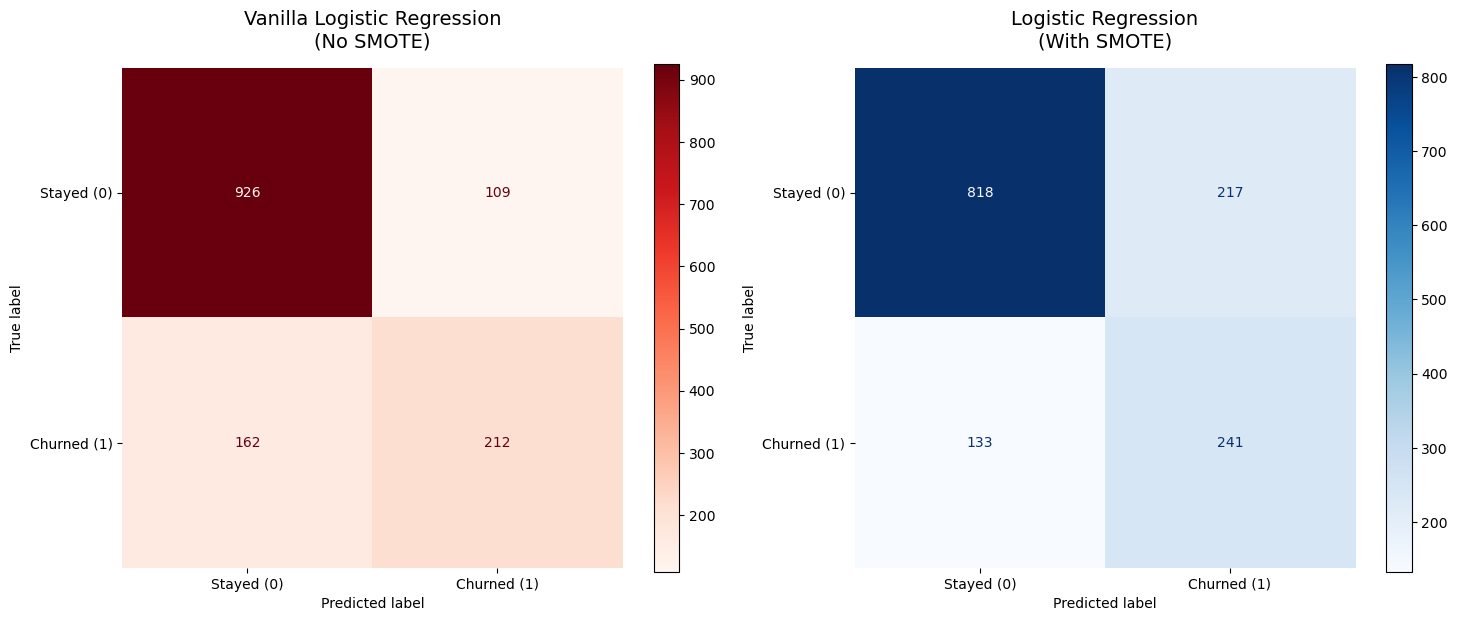

VANILLA REPORT (No SMOTE)
              precision  recall  f1-score  support
Stayed (0)         0.85    0.89      0.87   1035.0
Churned (1)        0.66    0.57      0.61    374.0
macro avg          0.76    0.73      0.74   1409.0
weighted avg       0.80    0.81      0.80   1409.0

SMOTE REPORT
              precision  recall  f1-score  support
Stayed (0)         0.86    0.79      0.82   1035.0
Churned (1)        0.53    0.64      0.58    374.0
macro avg          0.69    0.72      0.70   1409.0
weighted avg       0.77    0.75      0.76   1409.0


In [9]:
# --- Vanilla (no SMOTE, scaled) ---
X_train_scaled_vanilla = scaler.transform(X_train)   # same scaler, no refit
log_vanilla = LogisticRegression(max_iter=1000, random_state=42)
log_vanilla.fit(X_train_scaled_vanilla, y_train)
y_pred_vanilla = log_vanilla.predict(X_test_scaled)

# --- SMOTE model ---
log_smote = LogisticRegression(max_iter=1000, random_state=42)
log_smote.fit(X_train_res_scaled, y_train_res)
y_pred_smote = log_smote.predict(X_test_scaled)

# Confusion matrices side-by-side
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
for ax, model, title, cmap in zip(
    axes,
    [log_vanilla, log_smote],
    ["Vanilla Logistic Regression\n(No SMOTE)", "Logistic Regression\n(With SMOTE)"],
    ["Reds", "Blues"]
):
    ConfusionMatrixDisplay.from_estimator(
        model, X_test_scaled, y_test,
        cmap=cmap, ax=ax,
        display_labels=["Stayed (0)", "Churned (1)"],
        values_format="d"
    )
    ax.grid(False)
    for spine in ax.spines.values():
        spine.set_visible(False)
    ax.set_title(title, fontsize=14, pad=15)

plt.tight_layout()
plt.savefig("confusion_matrix_vanilla_vs_smote.png", dpi=200, bbox_inches="tight")
plt.show()

# Classification reports
def print_clean_report(y_true, y_pred, title):
    report = classification_report(
        y_true, y_pred,
        target_names=["Stayed (0)", "Churned (1)"],
        output_dict=True
    )
    report.pop("accuracy", None)
    print("=" * 55)
    print(title)
    print("=" * 55)
    print(pd.DataFrame(report).T.round(2))
    print("=" * 55)

print_clean_report(y_test, y_pred_vanilla, "VANILLA REPORT (No SMOTE)")
print()
print_clean_report(y_test, y_pred_smote,   "SMOTE REPORT")

# Metrics Comparison : Vanilla vs SMOTE (LogReg)

In [10]:
van_m   = get_metrics(log_vanilla, X_test_scaled, y_test)
smote_m = get_metrics(log_smote,   X_test_scaled, y_test)

metrics_comparison = pd.DataFrame({
    "Metric" : METRIC_NAMES,
    "Vanilla": list(van_m),
    "SMOTE"  : list(smote_m),
})
metrics_comparison["Difference"]    = metrics_comparison["SMOTE"] - metrics_comparison["Vanilla"]
metrics_comparison["Improvement %"] = (
    metrics_comparison["Difference"] / metrics_comparison["Vanilla"] * 100
)

print("\n" + "=" * 80)
print("COMPLETE METRICS COMPARISON – Vanilla vs SMOTE (LogReg)")
print("=" * 80)
print(metrics_comparison.round(4).to_string(index=False))
print("=" * 80)


COMPLETE METRICS COMPARISON – Vanilla vs SMOTE (LogReg)
   Metric  Vanilla  SMOTE  Difference  Improvement %
Precision   0.6604 0.5262     -0.1342       -20.3252
   Recall   0.5668 0.6444      0.0775        13.6792
 F1 Score   0.6101 0.5793     -0.0307        -5.0396
      MCC   0.4859 0.4098     -0.0761       -15.6557
  ROC AUC   0.8418 0.8023     -0.0396        -4.7005
   PR AUC   0.6302 0.5708     -0.0594        -9.4239


# ROC AUC + PR AUC Curves 

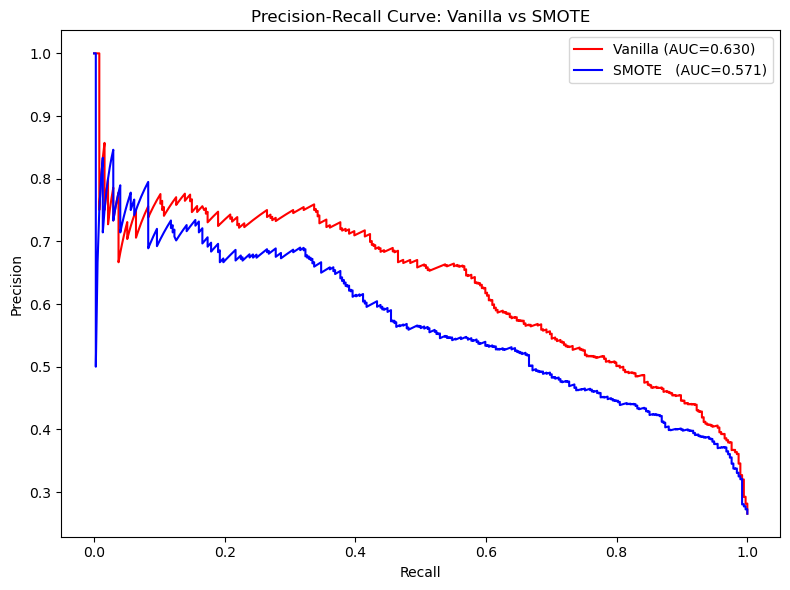


ROC AUC – Vanilla : 0.842
ROC AUC – SMOTE   : 0.802
PR  AUC – Vanilla : 0.630
PR  AUC – SMOTE   : 0.571


In [11]:
y_proba_vanilla = log_vanilla.predict_proba(X_test_scaled)[:, 1]
y_proba_smote   = log_smote.predict_proba(X_test_scaled)[:, 1]

prec_v, rec_v, _ = precision_recall_curve(y_test, y_proba_vanilla)
prec_s, rec_s, _ = precision_recall_curve(y_test, y_proba_smote)
pr_auc_vanilla   = auc(rec_v, prec_v)
pr_auc_smote     = auc(rec_s, prec_s)

plt.figure(figsize=(8, 6))
plt.plot(rec_v, prec_v, label=f"Vanilla (AUC={pr_auc_vanilla:.3f})", color="red")
plt.plot(rec_s, prec_s, label=f"SMOTE   (AUC={pr_auc_smote:.3f})",   color="blue")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve: Vanilla vs SMOTE")
plt.legend()
plt.tight_layout()
plt.savefig("pr_curve_vanilla_vs_smote.png", dpi=200, bbox_inches="tight")
plt.show()

roc_vanilla = roc_auc_score(y_test, y_proba_vanilla)
roc_smote   = roc_auc_score(y_test, y_proba_smote)
print(f"\nROC AUC – Vanilla : {roc_vanilla:.3f}")
print(f"ROC AUC – SMOTE   : {roc_smote:.3f}")
print(f"PR  AUC – Vanilla : {pr_auc_vanilla:.3f}")
print(f"PR  AUC – SMOTE   : {pr_auc_smote:.3f}")


# MCC Comparison 

In [12]:
mcc_vanilla = matthews_corrcoef(y_test, y_pred_vanilla)
mcc_smote   = matthews_corrcoef(y_test, y_pred_smote)

print("\n" + "=" * 70)
print("MCC COMPARISON")
print("=" * 70)
print(f"Vanilla MCC : {mcc_vanilla:.4f}")
print(f"SMOTE MCC   : {mcc_smote:.4f}")
print(f"Improvement : {mcc_smote - mcc_vanilla:+.4f}")



MCC COMPARISON
Vanilla MCC : 0.4859
SMOTE MCC   : 0.4098
Improvement : -0.0761


# TREE MODELS – RANDOM FOREST & XGBOOST (No SMOTE)

In [13]:
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()
print(f"\nscale_pos_weight for XGBoost: {scale_pos_weight:.3f}")

rf_model = RandomForestClassifier(
    n_estimators=500,
    max_depth=None,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)
rf_model.fit(X_train, y_train)   # unscaled, no SMOTE

xgb_model = XGBClassifier(
    n_estimators=300,
    learning_rate=0.1,
    max_depth=4,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=scale_pos_weight,
    random_state=42,
    n_jobs=-1,
    eval_metric="logloss"
)
xgb_model.fit(X_train, y_train)   # unscaled, no SMOTE

print("RF and XGBoost trained successfully.")

# Verify XGBoost probabilities
y_proba_xgb = xgb_model.predict_proba(X_test)[:, 1]
print(f"\nXGBoost proba – min: {y_proba_xgb.min():.4f}  "
      f"max: {y_proba_xgb.max():.4f}  mean: {y_proba_xgb.mean():.4f}")



scale_pos_weight for XGBoost: 2.769
RF and XGBoost trained successfully.

XGBoost proba – min: 0.0002  max: 0.9837  mean: 0.3744


# Algorithm Tournament :LogReg (SMOTE) vs RF vs XGBoost

/Users/blanca/opt/anaconda3/envs/churn_xgb/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
/Users/blanca/opt/anaconda3/envs/churn_xgb/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(



ALGORITHM TOURNAMENT
   Metric  LogReg (SMOTE)  Random Forest  XGBoost
Precision           0.526          0.625    0.530
   Recall           0.644          0.481    0.746
 F1 Score           0.579          0.544    0.620
      MCC           0.410          0.413    0.463
  ROC AUC           0.802          0.827    0.832
   PR AUC           0.571          0.622    0.636


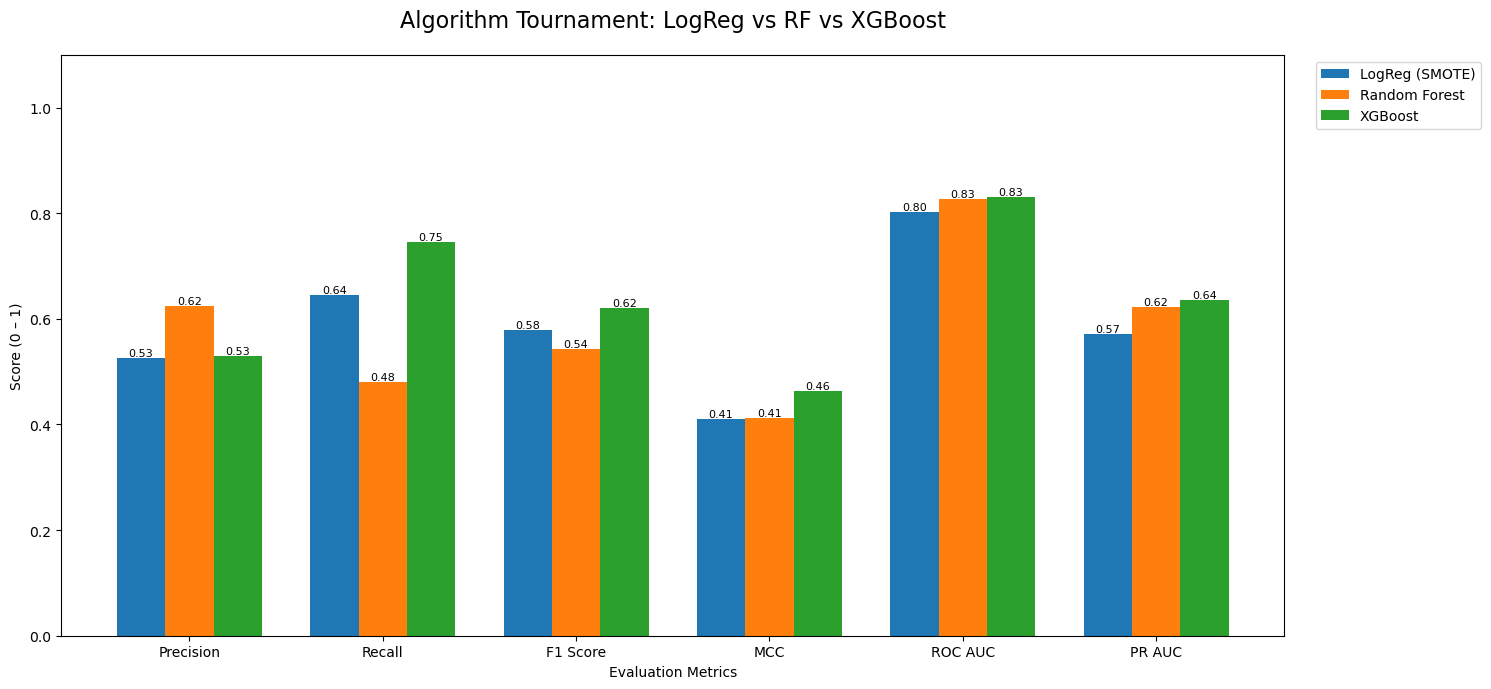

In [14]:
# LogReg uses scaled test set; tree models use unscaled test set
lr_m  = get_metrics(log_smote,  X_test_scaled,      y_test)
rf_m  = get_metrics(rf_model,   X_test.values,      y_test)
xgb_m = get_metrics(xgb_model,  X_test.values,      y_test)

metrics_all = pd.DataFrame({
    "Metric"               : METRIC_NAMES,
    "LogReg (SMOTE)"       : list(lr_m),
    "Random Forest"        : list(rf_m),
    "XGBoost"              : list(xgb_m),
})

print("\n" + "=" * 75)
print("ALGORITHM TOURNAMENT")
print("=" * 75)
print(metrics_all.round(3).to_string(index=False))
print("=" * 75)

# Grouped bar chart
x     = np.arange(len(METRIC_NAMES))
width = 0.25
fig, ax = plt.subplots(figsize=(15, 7))

b1 = ax.bar(x - width, metrics_all["LogReg (SMOTE)"], width, label="LogReg (SMOTE)")
b2 = ax.bar(x,          metrics_all["Random Forest"],  width, label="Random Forest")
b3 = ax.bar(x + width,  metrics_all["XGBoost"],        width, label="XGBoost")

for bars in [b1, b2, b3]:
    for bar in bars:
        h = bar.get_height()
        if h > 0:
            ax.text(bar.get_x() + bar.get_width() / 2, h,
                    f"{h:.2f}", ha="center", va="bottom", fontsize=8)

ax.set_title("Algorithm Tournament: LogReg vs RF vs XGBoost", fontsize=16, pad=20)
ax.set_ylabel("Score (0 – 1)")
ax.set_xlabel("Evaluation Metrics")
ax.set_xticks(x)
ax.set_xticklabels(METRIC_NAMES)
ax.set_ylim(0, 1.10)
ax.legend(loc="upper left", bbox_to_anchor=(1.02, 1))
ax.grid(False)
plt.tight_layout()
plt.savefig("algorithm_tournament.png", dpi=200, bbox_inches="tight")
plt.show()

filtered metrics chart 

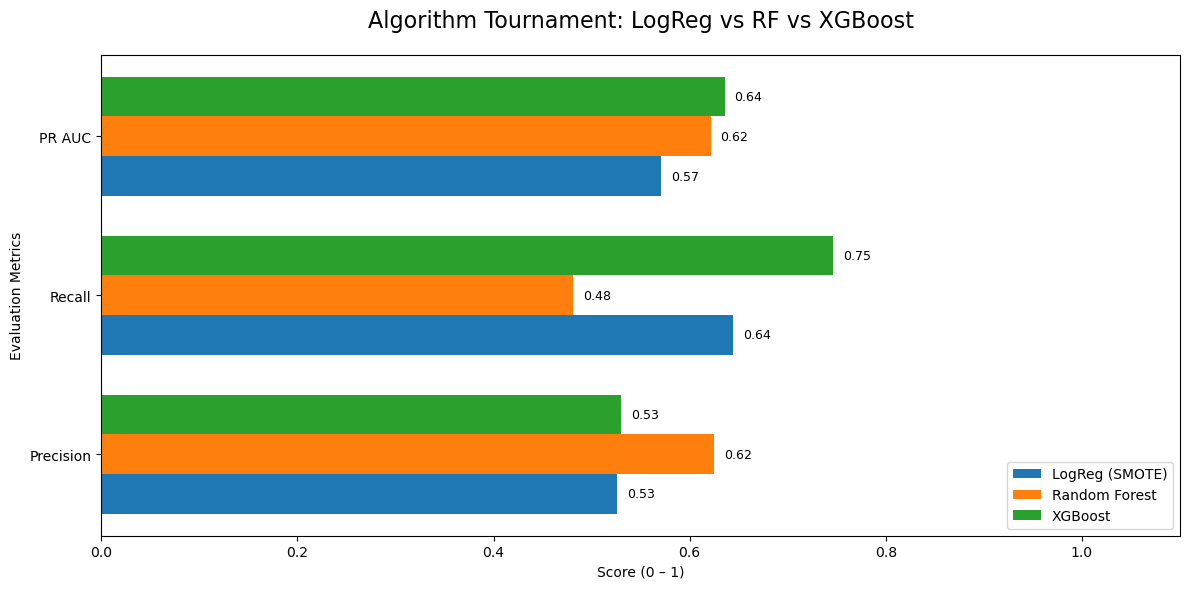

In [20]:
# Select only desired metrics
selected_metrics = ["PR AUC", "Recall", "Precision"]
metrics_filtered = metrics_all[metrics_all["Metric"].isin(selected_metrics)].reset_index(drop=True)

# Positions
y = np.arange(len(metrics_filtered["Metric"]))
height = 0.25

fig, ax = plt.subplots(figsize=(12, 6))

# Horizontal grouped bars
b1 = ax.barh(y - height, metrics_filtered["LogReg (SMOTE)"], height, label="LogReg (SMOTE)")
b2 = ax.barh(y,           metrics_filtered["Random Forest"], height, label="Random Forest")
b3 = ax.barh(y + height,  metrics_filtered["XGBoost"],       height, label="XGBoost")

# Annotate bars
for bars in [b1, b2, b3]:
    for bar in bars:
        w = bar.get_width()
        if w > 0:
            ax.text(w + 0.01, bar.get_y() + bar.get_height()/2,
                    f"{w:.2f}", va="center", fontsize=9)

# Labels and formatting
ax.set_title("Algorithm Tournament: LogReg vs RF vs XGBoost", fontsize=16, pad=20)
ax.set_xlabel("Score (0 – 1)")
ax.set_ylabel("Evaluation Metrics")

ax.set_yticks(y)
ax.set_yticklabels(metrics_filtered["Metric"])

ax.set_xlim(0, 1.10)

ax.legend(loc="lower right")
ax.grid(False)

plt.tight_layout()
plt.savefig("algorithm_tournament_horizontal.png", dpi=200, bbox_inches="tight")
plt.show()

# HYPERPARAMETER TUNING  (GridSearchCV, scoring=roc_auc)

In [16]:
# Logistic Regression 
log_param_grid = {
    "C"            : [0.01, 0.1, 1, 10],
    "class_weight" : [None, "balanced"],
    "max_iter"     : [500, 1000],
}
log_grid = GridSearchCV(
    LogisticRegression(), log_param_grid,
    scoring="roc_auc", cv=5, n_jobs=-1, verbose=1
)
log_grid.fit(X_train_res_scaled, y_train_res)   # scaled SMOTE data
best_log_reg = log_grid.best_estimator_
print("Best LogReg params:", log_grid.best_params_)

# Random Forest 
rf_param_grid = {
    "n_estimators"    : [200, 300, 500],
    "max_depth"       : [None, 10, 20],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
    "max_features"    : ["sqrt", "log2"],
}
rf_grid = GridSearchCV(
    RandomForestClassifier(random_state=42), rf_param_grid,
    scoring="roc_auc", cv=5, n_jobs=-1, verbose=1
)
rf_grid.fit(X_train.values, y_train)   # unscaled, no SMOTE
rf_model_tuned = rf_grid.best_estimator_
print("Best RF params:", rf_grid.best_params_)

# XGBoost 
xgb_param_grid = {
    "n_estimators"    : [200, 300],
    "learning_rate"   : [0.05, 0.1],
    "max_depth"       : [3, 4, 5],
    "subsample"       : [0.8, 1.0],
    "colsample_bytree": [0.8, 1.0],
}
xgb_grid = GridSearchCV(
    XGBClassifier(random_state=42, n_jobs=-1,
                  eval_metric="logloss",
                  scale_pos_weight=scale_pos_weight),
    xgb_param_grid,
    scoring="roc_auc", cv=5, n_jobs=-1, verbose=1
)
xgb_grid.fit(X_train.values, y_train)   # unscaled, no SMOTE
xgb_model_tuned = xgb_grid.best_estimator_
print("Best XGB params:", xgb_grid.best_params_)


Fitting 5 folds for each of 16 candidates, totalling 80 fits
Best LogReg params: {'C': 10, 'class_weight': 'balanced', 'max_iter': 500}
Fitting 5 folds for each of 162 candidates, totalling 810 fits
Best RF params: {'max_depth': 10, 'max_features': 'log2', 'min_samples_leaf': 4, 'min_samples_split': 10, 'n_estimators': 500}
Fitting 5 folds for each of 48 candidates, totalling 240 fits
Best XGB params: {'colsample_bytree': 1.0, 'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 200, 'subsample': 0.8}


# Tuned Model Evaluation 

In [17]:
# LogReg was tuned on scaled data  → evaluate on X_test_scaled
# RF / XGB were tuned on raw data  → evaluate on X_test.values
log_tuned_metrics = get_metrics(best_log_reg,    X_test_scaled, y_test)
rf_tuned_metrics  = get_metrics(rf_model_tuned,  X_test.values, y_test)
xgb_tuned_metrics = get_metrics(xgb_model_tuned, X_test.values, y_test)

tuned_comparison = pd.DataFrame({
    "Metric"              : METRIC_NAMES,
    "LogReg (tuned)"      : list(log_tuned_metrics),
    "Random Forest (tuned)": list(rf_tuned_metrics),
    "XGBoost (tuned)"     : list(xgb_tuned_metrics),
})

print("\n" + "=" * 75)
print("TUNED MODEL COMPARISON")
print("=" * 75)
print(tuned_comparison.round(3).to_string(index=False))
print("=" * 75)


TUNED MODEL COMPARISON
   Metric  LogReg (tuned)  Random Forest (tuned)  XGBoost (tuned)
Precision           0.530                  0.676            0.509
   Recall           0.644                  0.508            0.794
 F1 Score           0.581                  0.580            0.620
      MCC           0.413                  0.464            0.463
  ROC AUC           0.802                  0.845            0.846
   PR AUC           0.569                  0.659            0.665


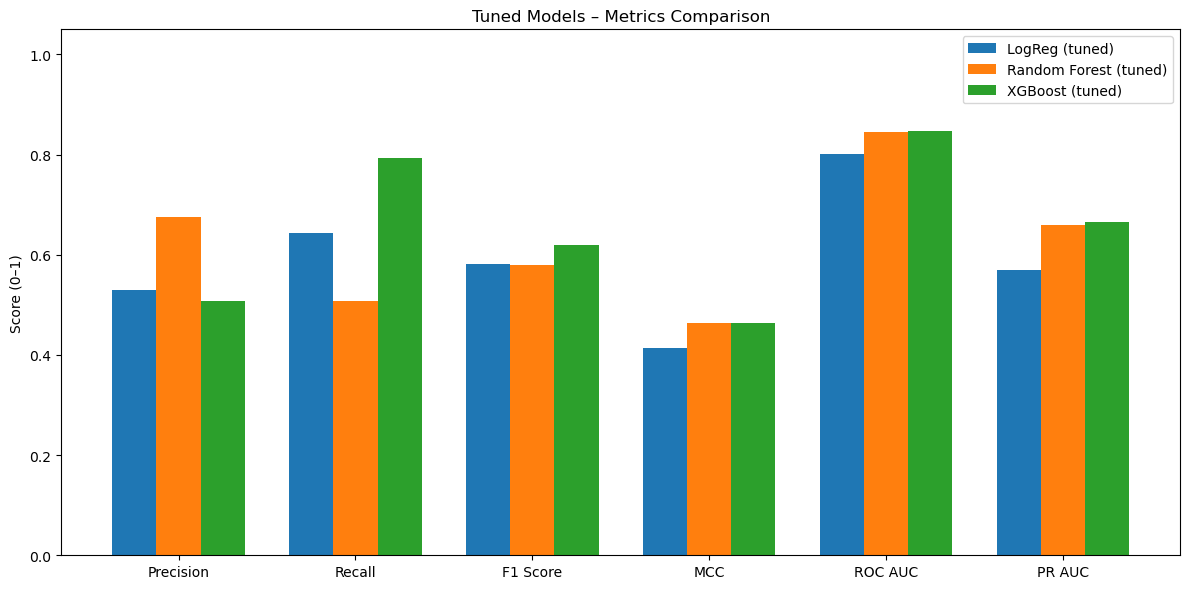

In [18]:
metrics = METRIC_NAMES
logreg = list(log_tuned_metrics)
rf     = list(rf_tuned_metrics)
xgb    = list(xgb_tuned_metrics)

x = np.arange(len(metrics))
width = 0.25

plt.figure(figsize=(12, 6))
plt.bar(x - width, logreg, width, label="LogReg (tuned)")
plt.bar(x,         rf,     width, label="Random Forest (tuned)")
plt.bar(x + width, xgb,    width, label="XGBoost (tuned)")

plt.xticks(x, metrics)
plt.ylabel("Score (0–1)")
plt.title("Tuned Models – Metrics Comparison")
plt.ylim(0, 1.05)
plt.legend()
plt.tight_layout()
plt.show()


# Business Objective: Model Recommendation 

In [19]:
objective = "recall"   # change to: "precision" or "balanced"

def _get(df, metric, col):
    row = df.loc[df["Metric"] == metric, col]
    return float(row.values[0]) if len(row) else np.nan

models_info = {
    "LogReg (tuned)": {
        "Recall"   : _get(tuned_comparison, "Recall",    "LogReg (tuned)"),
        "Precision": _get(tuned_comparison, "Precision", "LogReg (tuned)"),
        "MCC"      : _get(tuned_comparison, "MCC",       "LogReg (tuned)"),
        "PR AUC"   : _get(tuned_comparison, "PR AUC",    "LogReg (tuned)"),
    },
    "Random Forest (tuned)": {
        "Recall"   : _get(tuned_comparison, "Recall",    "Random Forest (tuned)"),
        "Precision": _get(tuned_comparison, "Precision", "Random Forest (tuned)"),
        "MCC"      : _get(tuned_comparison, "MCC",       "Random Forest (tuned)"),
        "PR AUC"   : _get(tuned_comparison, "PR AUC",    "Random Forest (tuned)"),
    },
    "XGBoost (tuned)": {
        "Recall"   : _get(tuned_comparison, "Recall",    "XGBoost (tuned)"),
        "Precision": _get(tuned_comparison, "Precision", "XGBoost (tuned)"),
        "MCC"      : _get(tuned_comparison, "MCC",       "XGBoost (tuned)"),
        "PR AUC"   : _get(tuned_comparison, "PR AUC",    "XGBoost (tuned)"),
    },
}

sort_key = {"recall": "Recall", "precision": "Precision", "balanced": "MCC"}[objective]
winner = max(models_info, key=lambda m: (models_info[m][sort_key], models_info[m]["PR AUC"]))

print("\n" + "=" * 70)
print("MODEL RECOMMENDATION")
print("=" * 70)
print(f"Objective        : {objective.upper()}")
print(f"Recommended model: {winner}")
for m, v in models_info[winner].items():
    print(f"  {m:12s}: {v:.3f}")
print("=" * 70)


MODEL RECOMMENDATION
Objective        : RECALL
Recommended model: XGBoost (tuned)
  Recall      : 0.794
  Precision   : 0.509
  MCC         : 0.463
  PR AUC      : 0.665
